## №4 **(6 баллов)**

Проведите всесторонний анализ и визуализацию данных. 

Пользуйтесь https://cloud.mail.ru/public/A8ie/9dJHy8iHo, материалами лекции и другими доступными источниками.

1. Используя ресурс kaggle (https://www.kaggle.com/), выберите один из наборов данных. Загрузите этот набор и выведите первые 10 записей на экран.

---

ВЫБРАН: https://www.kaggle.com/datasets/wardabilal/spotify-global-music-dataset-20092025

In [46]:
import pandas as pd
import numpy as np
import seaborn as sb
from matplotlib import pyplot as plt

df = pd.read_csv("spotify_data clean.csv")
df.head(10)

,track_id,track_name,track_number,track_popularity,explicit,artist_name,artist_popularity,artist_followers,artist_genres,album_id,album_name,album_release_date,album_total_tracks,album_type,track_duration_min
0,3EJS5LyekDim1Tf5rBFmZl,Trippy Mane (ft. Project Pat),4,0,True,Diplo,77,2812821,moombahton,5QRFnGnBeMGePBKF2xTz5z,"d00mscrvll, Vol. 1",2025-10-31,9,album,1.55
1,1oQW6G2ZiwMuHqlPpP27DB,OMG!,1,0,True,Yelawolf,64,2363438,"country hip hop, southern hip hop",4SUmmwnv0xTjRcLdjczGg2,OMG!,2025-10-31,1,single,3.07
2,7mdkjzoIYlf1rx9EtBpGmU,Hard 2 Find,1,4,True,Riff Raff,48,193302,NaN,3E3zEAL8gUYWaLYB9L7gbp,Hard 2 Find,2025-10-31,1,single,2.55
3,67rW0Zl7oB3qEpD5YWWE5w,Still Get Like That (ft. Project Pat & Starrah),8,30,True,Diplo,77,2813710,moombahton,5QRFnGnBeMGePBKF2xTz5z,"d00mscrvll, Vol. 1",2025-10-31,9,album,1.69
4,15xptTfRBrjsppW0INUZjf,ride me like a harley,2,0,True,Rumelis,48,8682,dark r&b,06FDIpSHYmZAZoyuYtc7kd,come closer / ride me like a harley,2025-10-30,2,single,2.39
5,4ccpCcZYseq8VrPMK1EDs0,BLEED,1,2,False,Minzie,46,7218,dark r&b,2NQv9p3ZQW0Ed1LB9enix8,BLEED,2025-10-30,3,single,2.76
6,3QoQ3HqXTAjgEl9LbNMbYp,Te Procuro na Cidade,1,20,False,AZERDK,30,1657,NaN,1PpuOsLjPWshDLxkr0oHeU,Te Procuro na Cidade,2025-10-30,1,single,4.12
7,1YEZbdT417SfolPQzaoHs2,come closer,1,27,False,Rumelis,49,8802,dark r&b,06FDIpSHYmZAZoyuYtc7kd,come closer / ride me like a harley,2025-10-30,2,single,2.53
8,4pZ949nFW5SurwzE0TSe7I,Cupido Vagabundo,1,16,False,Toni dos Anjos,6,475,NaN,60DLQZkzpvDvVfvEC6VOJM,Cupido Vagabundo,2025-10-30,2,single,2.92
9,0L0LgwFZ7UtBnRNQvSBty6,LET’S GO!,1,33,True,PsychoYP,48,154802,"nigerian drill, alté, afro adura, afrobeats, a...",3ARxksm8CspGeAaZZB1v2w,LET’S GO!,2025-10-28,1,single,2.40


---

2. Опишите данные набора: какие признаки в нем присутствуют, что они означают, какой у них тип данных, какие значения могут принимать.

In [8]:
desc = pd.DataFrame({
    "column": df.columns,
    "dtype": [str(t) for t in df.dtypes],
    "missing": df.isna().sum().values,
    "missing_%": (df.isna().mean() * 100).round(2).values,
    "unique": df.nunique(dropna=True).values,
    "examples": [df[c].dropna().astype(str).head(3).tolist() for c in df.columns],
})
desc

,column,dtype,missing,missing_%,unique,examples
0,track_id,object,0,0.00,8582,"[3EJS5LyekDim1Tf5rBFmZl, 1oQW6G2ZiwMuHqlPpP27D..."
1,track_name,object,0,0.00,7462,"[Trippy Mane (ft. Project Pat), OMG!, Hard 2 F..."
2,track_number,int64,0,0.00,54,"[4, 1, 1]"
3,track_popularity,int64,0,0.00,98,"[0, 0, 4]"
4,explicit,bool,0,0.00,2,"[True, True, True]"
5,artist_name,object,3,0.03,2547,"[Diplo, Yelawolf, Riff Raff]"
6,artist_popularity,int64,0,0.00,96,"[77, 64, 48]"
7,artist_followers,int64,0,0.00,3740,"[2812821, 2363438, 193302]"
8,artist_genres,object,3361,39.16,661,"[moombahton, country hip hop, southern hip hop..."
9,album_id,object,0,0.00,5205,"[5QRFnGnBeMGePBKF2xTz5z, 4SUmmwnv0xTjRcLdjczGg..."


**СЛОВАМИ**

Колонки:
- track_id = айди трека;
- track_name = название трека;
- track_number = номер трека;
- track_popularity = популярность трека;
- explicit = наличие "контента для взрослых" в тексте;
- artist_name = исполнитель;
- artist_followers = число подписчиков исполнителя;
- artst_genres = жанры исполнителя;
- album_id = айди альбома;
- album_name = название альбома;
- album_release_date = дата выхода альбома;
- album_total_tracks = общее число треков в альбоме;
- album_type = тип альбома;
- track_duration_min = продолжительность трека в минутах.

Тип данных и значения видны в таблице.

---

3. Укажите какие признаки являются количественными, качественными порядковыми и качественными номинальными.

#### КОЛИЧЕСТВЕННЫЕ
- track_number (int) — номер трека = число
- track_popularity (int) — популярность в виде числового показателя.
- artist_popularity (int) — популярность артиста (число).
- artist_followers (int) — число подписчиков (счётчик).
- album_total_tracks (int) — количество треков в альбоме (счётчик).
- track_duration_min (float) — длительность (измерение).

#### Качественные ПОРЯДКОВЫЕ
В нашем случае явных порядковых признаков считай что нет
- track_number можно считать порядковым только внутри одного альбома
- album_release_date — это дата (временная шкала с порядком), но это не качественный признак
- track_popularity (int) — также можно считать порядковым если мы сгруппируем по категориям
- artist_popularity (int) — также можно считать порядковым если мы сгруппируем по категориям

#### Качественные НОМИНАЛЬНЫЕ
- track_id — айди трека (строка‑ID, порядка нет).
- track_name — название трека.
- artist_name — исполнитель.
- artist_genres — жанры (категории; порядка нет).
- album_id — айди альбома;
- album_name — название альбома.
- album_type — тип альбома (album, single, …) — категории без порядка.
- explicit (bool) — бинарная категория “да/нет”.

---

4. Рассчитайте параметры описательной статистики для признаков набора.

In [10]:
# 1) Числовые признаки
num_cols = ["track_popularity", "artist_popularity", "artist_followers",
            "album_total_tracks", "track_duration_min", "track_number"]
df[num_cols].describe()

,track_popularity,artist_popularity,artist_followers,album_total_tracks,track_duration_min,track_number
count,8582.000000,8582.000000,8.582000e+03,8582.000000,8582.000000,8582.000000
mean,52.356211,69.730016,2.403472e+07,13.789443,3.492805,5.772547
std,23.816076,19.645979,3.803180e+07,11.887131,1.057970,6.052792
min,0.000000,0.000000,0.000000e+00,1.000000,0.070000,1.000000
25%,39.000000,60.000000,4.623200e+05,6.000000,2.880000,1.000000
50%,58.000000,74.000000,6.105547e+06,13.000000,3.445000,4.000000
75%,71.000000,84.000000,2.725255e+07,17.000000,3.990000,9.000000
max,99.000000,100.000000,1.455421e+08,181.000000,13.510000,102.000000


In [11]:
# 2) Категориальные признаки
cat_cols = ["explicit", "album_type", "artist_genres", "track_name", "artist_name"]
df[cat_cols].describe(include="all")

,explicit,album_type,artist_genres,track_name,artist_name
count,8582,8582,5221,8582,8579
unique,2,3,661,7462,2547
top,False,album,soundtrack,Home,Taylor Swift
freq,6434,5856,345,8,324


С помощью параметров описательной статистики опишите один из количественных признаков и один из категориальных признаков.

**Один из количественных:**

In [19]:
df["artist_popularity"].describe()

count    8582.000000
mean       69.730016
std        19.645979
min         0.000000
25%        60.000000
50%        74.000000
75%        84.000000
max       100.000000
Name: artist_popularity, dtype: float64

**Один из категориальных:**

In [20]:
df["album_type"].describe()

count      8582
unique        3
top       album
freq       5856
Name: album_type, dtype: object

Есть ли в количественном признаке выбросы?

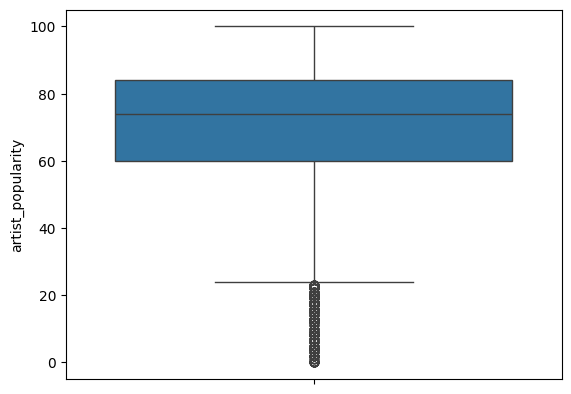

In [18]:
ax = sb.boxplot(data=df, y="artist_popularity")

**ОТВЕТ:** Да, есть в нижнем квантиле.

Какое значение является выбросом и почему?

**ОТВЕТ:** boxplot (ящик с усами) является удобной визуализацией выбросов т.к. функция сама расчитывает выбросы по правилу 1.5 расстояния от 1го и 3го квантилей соответственно. Всё, что находится за усами = выбросы.

По какому категориальному признаку можно группировать данные?

**ОТВЕТ:** например, по explicit (true/false категории), по album_type (album/single/compilation)

Какие группировки представляют интерес и почему?

**ОТВЕТ:** вообще наиболее интересной, как мне кажется, была бы "ручная" группировка. Не по категориальным признакам, а по количественным (популярность, например). Разделить на группы и смотреть далее, так можно сделать вывод о количестве популярных артистов, например, какой % входит в какую статистику (как, допустим, мы считаем что богатейшими людьми мира является 0.5% населения и т.д. т.п.)

---

5. Постройте графики для количественных и категориальных признаков.

Какие визуализации построены для количественных признаков?

**ОТВЕТ:** в данном случае строим гистограмму и ящик с усами 

Какие особенности распределения данных они позволяют наблюдать?

<Axes: xlabel='track_popularity', ylabel='Count'>

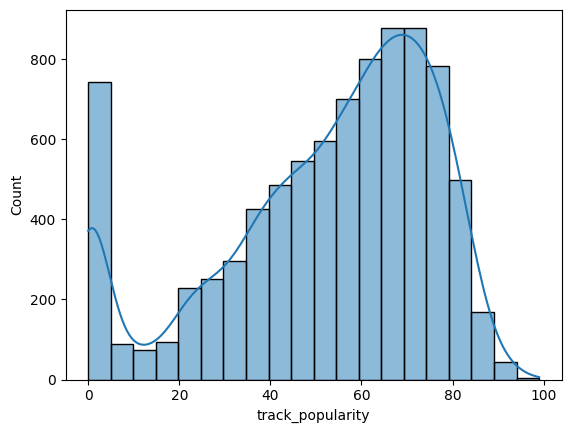

In [29]:
sb.histplot(data=df, x="track_popularity", bins=20, kde=True)

<Axes: ylabel='track_popularity'>

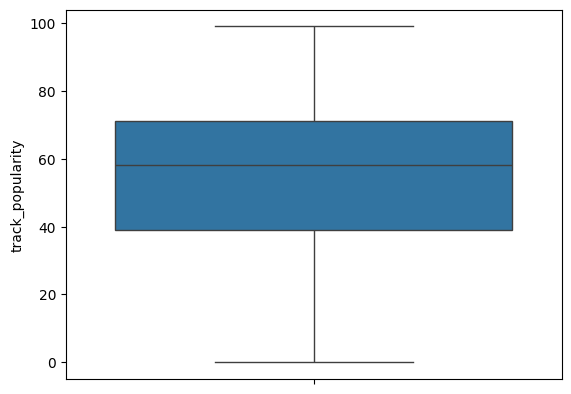

In [30]:
sb.boxplot(data=df, y="track_popularity")

**Особенности распределения:** видно что наибольшее число треков либо абсолютно непопулярно, либо находится в границе 50-80, преимуществено в районе 60.

Какие визуализации построены для категориальных признаков?

Какие особенности распределения данных они позволяют наблюдать?

**ОТВЕТ:** для категориальных построены частоты категорий.

Позволяют наблюдать дисбаланс классов

<Axes: xlabel='explicit', ylabel='count'>

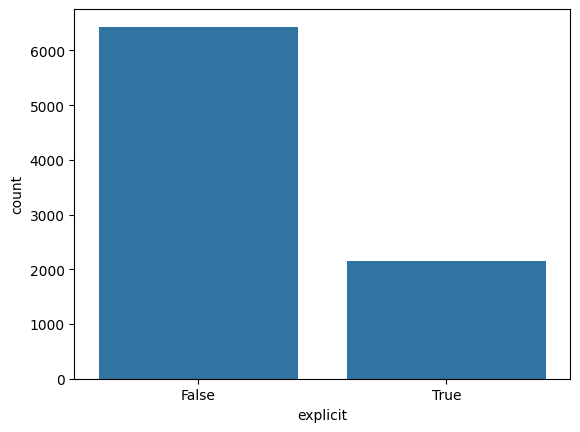

In [34]:
sb.countplot(data=df, x="explicit")

<Axes: xlabel='album_type', ylabel='count'>

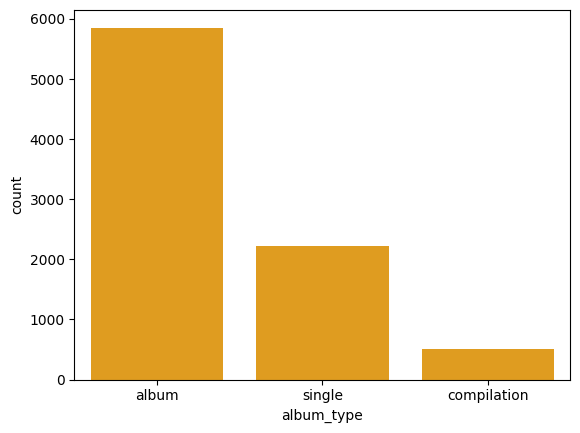

In [36]:
sb.countplot(data=df, x="album_type", color='orange')

Какие визуализации построены для пар признаков?

Какие особенности распределения данных они позволяют наблюдать?

**ОТВЕТ:** В первом графике: построено соотношение числа подписчиков исполнителя и популярности треков.
Видим, что корреляция не линейна

<Axes: xlabel='artist_followers', ylabel='track_popularity'>

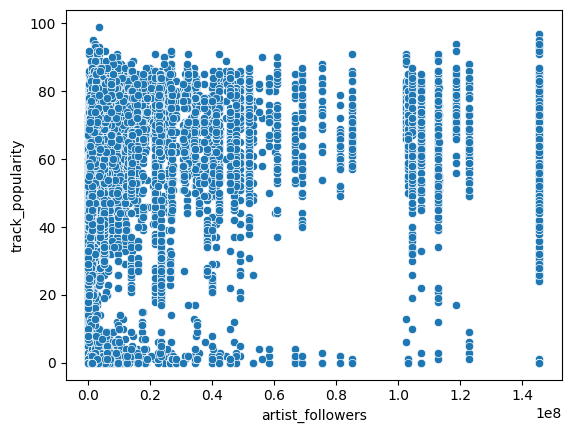

In [37]:
sb.scatterplot(data=df, x="artist_followers", y="track_popularity")

<Axes: xlabel='explicit', ylabel='track_popularity'>

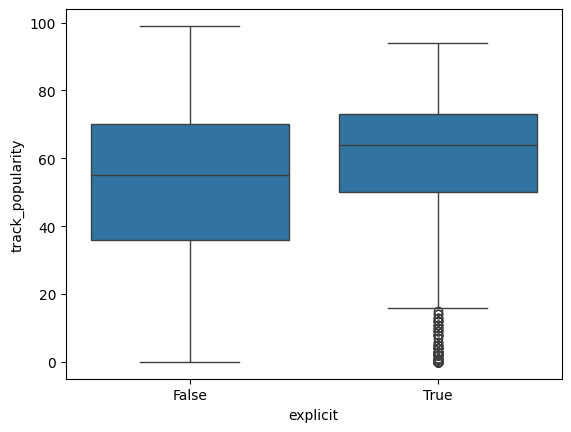

In [38]:
sb.boxplot(data=df, x="explicit", y="track_popularity")

---

6. Проведите корреляционный анализ. 

Есть ли в вашем наборе данных коррелирующие признаки?

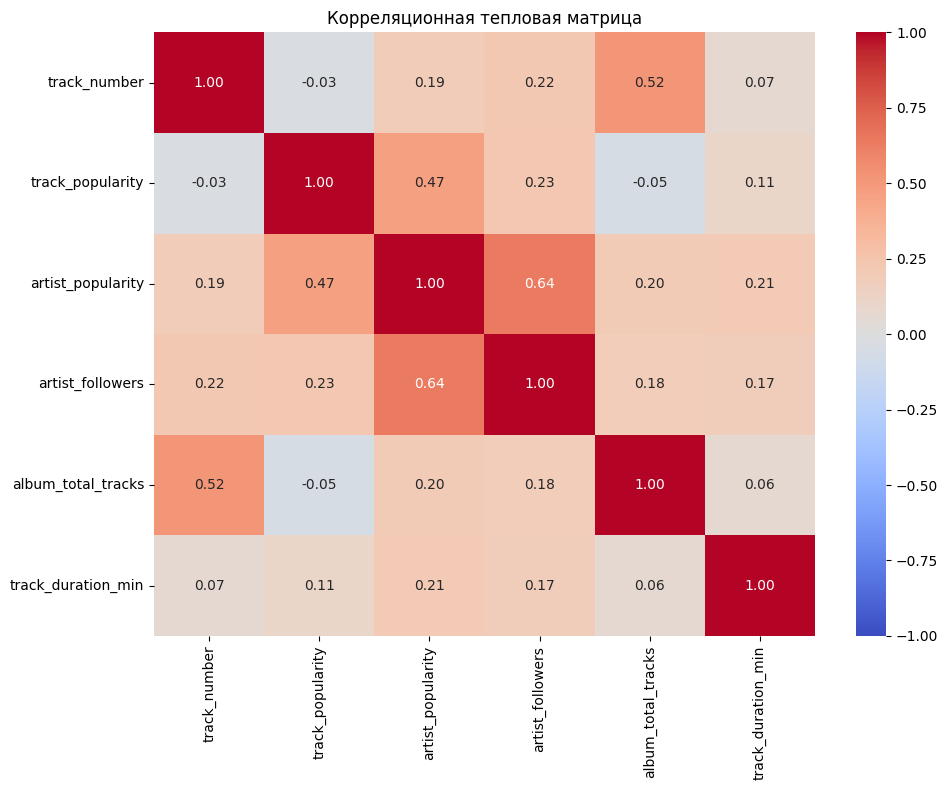

In [51]:
num = df.select_dtypes(include="number")
corr = num.corr(method="pearson")   # / "spearman"

plt.figure(figsize=(10, 8))
sb.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Корреляционная тепловая матрица")
plt.tight_layout()
plt.show()

**ОТВЕТ:** 
- популярность исполнителя коррелирует с популярностью треков
- количество подписчиков исполнителя коррелирует с его популярностью
- количество общих треков на альбоме коррелирует с номером трека (что логично, по сути одно и то же в контексте)